In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, average_precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (227845, 30)
Test set: (56962, 30)


In [8]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
    ])
}

In [9]:
results = []

for name, pipeline in pipelines.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'AUC-PR': round(average_precision_score(y_test, y_scores), 4)
    })
    
    print(f"  Done. F1: {f1_score(y_test, y_pred):.4f}")

print("\nAll models trained.")

Training Logistic Regression...
  Done. F1: 0.1088
Training Random Forest...
  Done. F1: 0.8482
Training XGBoost...
  Done. F1: 0.7850

All models trained.


In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print(results_df)

                     Precision  Recall  F1 Score  AUC-PR
Model                                                   
Logistic Regression     0.0578  0.9184    0.1088  0.7245
Random Forest           0.8710  0.8265    0.8482  0.8723
XGBoost                 0.7241  0.8571    0.7850  0.8671


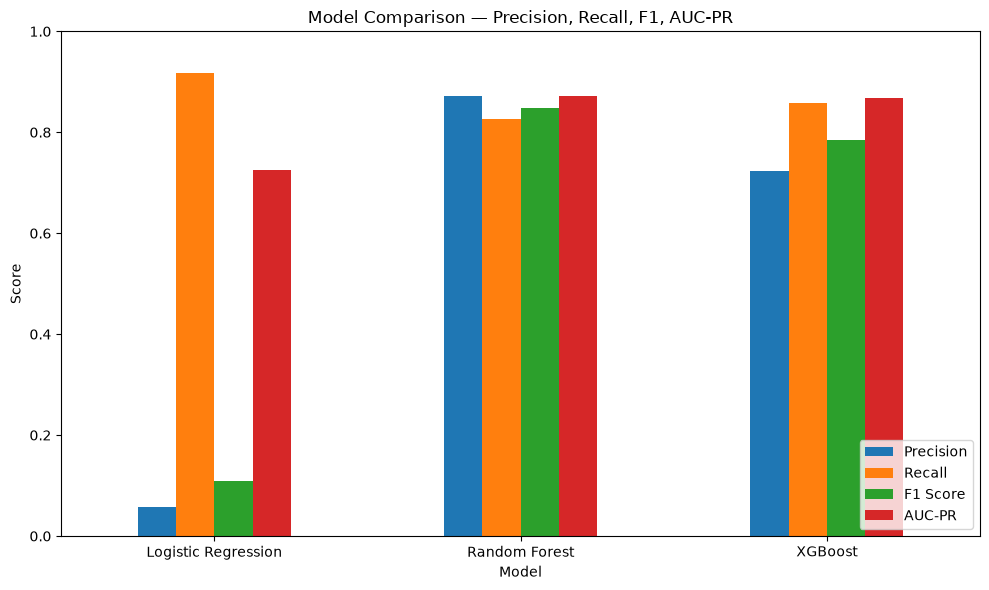

In [11]:
results_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1))
plt.title('Model Comparison — Precision, Recall, F1, AUC-PR')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png')
plt.show()

In [13]:
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    print(f"\n- {name} -")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))


- Logistic Regression -
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


- Random Forest -
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


- XGBoost -
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.72      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg     

In [ ]:
#Reprint classification report for XGBoost cause of cutoff

from sklearn.metrics import classification_report
y_pred_xgb = pipelines['XGBoost'].predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.72      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

